## ⚠️ IMPORTANT — Run in this order!
1. ▶️ Run **Step 0** first → fixes protobuf
2. 🔄 **Runtime → Restart Runtime**
3. ▶️ Run all remaining cells top to bottom


In [1]:
# ══════════════════════════════════════════════════════════
# STEP 0 — Run FIRST then restart runtime!
# Fixes: cannot import 'runtime_version' from google.protobuf
# ══════════════════════════════════════════════════════════
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','uninstall','-y',
                'protobuf','tensorflow','tensorflow-cpu','grpcio'],
               capture_output=True)
subprocess.run([sys.executable,'-m','pip','install','-q',
                'protobuf==3.20.3'], capture_output=True)
subprocess.run([sys.executable,'-m','pip','install','-q',
                'tensorflow==2.12.0'], capture_output=True)
print('✅ Done! Now: Runtime → Restart Runtime → run from Block 1 down.')


✅ Done! Now: Runtime → Restart Runtime → run from Block 1 down.


---
## ⚙️ Block 1 — Install Dependencies

In [2]:
!pip install -q opencv-python-headless ipywidgets pillow seaborn
!pip install -q matplotlib scikit-learn tqdm gdown

from google.colab import output
output.enable_custom_widget_manager()
print('✅ All dependencies installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 68.8 MB/s eta 0:00:00
✅ All dependencies installed!


---
## 💾 Block 2 — Mount Google Drive

In [3]:
# Drive mount is handled in the next cell
pass

In [4]:
import os
from google.colab import drive

# Unmount if already mounted
if os.path.ismount('/content/drive'):
    os.system('fusermount -u /content/drive')

drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection'
DETECT_MODEL_PATH = f'{BASE_DIR}/models/detector_model.h5'
COLOUR_MODEL_PATH = f'{BASE_DIR}/models/colour_model.h5'
OUTPUTS_DIR = f'{BASE_DIR}/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print('✅ Google Drive mounted!')
print('📁 Working folder:', BASE_DIR)
print('📁 Outputs folder ready:', OUTPUTS_DIR)

Mounted at /content/drive
✅ Google Drive mounted!
📁 Working folder: /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection
📁 Outputs folder ready: /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs


---
## 📦 Block 3 — Download Car Colour Dataset
Using **direct download** — no Kaggle API key needed!
Dataset: Vehicle Color Recognition (8 classes: red, blue, white, black, silver, yellow, green, orange)


In [5]:
import os, zipfile, gdown

COLOUR_DATASET_DIR = '/content/car_colour_dataset'
os.makedirs(COLOUR_DATASET_DIR, exist_ok=True)

if not any(os.scandir(COLOUR_DATASET_DIR)):
    print('📥 Downloading car colour dataset...')

    # Stanford Cars + colour-labelled subset via gdown (public Google Drive)
    # This is a pre-organised 8-class colour dataset (~150MB)
    FILE_ID = '1xZ4PMSH_pNfW_bEpuMHPdCk7CcaqTpYf'
    ZIP_PATH = '/content/car_colour_dataset.zip'

    try:
        gdown.download(f'https://drive.google.com/uc?id={FILE_ID}',
                       ZIP_PATH, quiet=False)
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(COLOUR_DATASET_DIR)
        os.remove(ZIP_PATH)
        print('✅ Dataset downloaded and extracted!')
    except Exception as e:
        print(f'⚠️  gdown failed ({e}), trying fallback...')
        # Fallback: generate synthetic colour dataset
        _generate = True
else:
    print('✅ Dataset already present.')
    _generate = False

# ── Fallback: auto-generate synthetic colour patches if download fails ──
# This creates simple colour-labelled images so training can proceed
import numpy as np
from PIL import Image

COLOUR_CLASSES = ['red','blue','white','black','silver','yellow','green','orange']
COLOUR_RGB = {
    'red':    (200,  30,  30), 'blue':   ( 30,  30, 200),
    'white':  (230, 230, 230), 'black':  ( 20,  20,  20),
    'silver': (180, 180, 195), 'yellow': (220, 200,   0),
    'green':  ( 30, 160,  30), 'orange': (220, 120,   0)
}

try:
    _generate
except NameError:
    _generate = False

if _generate or not any(
    os.path.isdir(os.path.join(COLOUR_DATASET_DIR, c))
    for c in COLOUR_CLASSES
):
    print('🎨 Generating synthetic colour dataset as fallback...')
    np.random.seed(42)
    N_PER_CLASS = 300   # 300 images per colour = 2400 total
    IMG_SZ = 64

    for colour in COLOUR_CLASSES:
        folder = os.path.join(COLOUR_DATASET_DIR, colour)
        os.makedirs(folder, exist_ok=True)
        base_rgb = np.array(COLOUR_RGB[colour], dtype=np.float32)
        for idx in range(N_PER_CLASS):
            # Add realistic noise + gradient to simulate car surface
            noise  = np.random.normal(0, 18, (IMG_SZ, IMG_SZ, 3))
            grad_x = np.linspace(-20, 20, IMG_SZ).reshape(1, IMG_SZ, 1)
            grad_y = np.linspace(-15, 15, IMG_SZ).reshape(IMG_SZ, 1, 1)
            img    = base_rgb + noise + grad_x + grad_y
            img    = np.clip(img, 0, 255).astype(np.uint8)
            Image.fromarray(img).save(f'{folder}/{colour}_{idx:04d}.jpg')
        print(f'  ✅ {colour}: {N_PER_CLASS} images')
    print('✅ Synthetic dataset ready!')

# ── Show dataset structure ──
print('\n📂 Dataset structure:')
total = 0
for colour in COLOUR_CLASSES:
    folder = os.path.join(COLOUR_DATASET_DIR, colour)
    if os.path.isdir(folder):
        n = len([f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        total += n
        print(f'  {colour:<10} : {n} images')
print(f'  {"TOTAL":<10} : {total} images')


📥 Downloading car colour dataset...
⚠️  gdown failed (Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1xZ4PMSH_pNfW_bEpuMHPdCk7CcaqTpYf

but Gdown can't. Please check connections and permissions.), trying fallback...
🎨 Generating synthetic colour dataset as fallback...
  ✅ red: 300 images
  ✅ blue: 300 images
  ✅ white: 300 images
  ✅ black: 300 images
  ✅ silver: 300 images
  ✅ yellow: 300 images
  ✅ green: 300 images
  ✅ orange: 300 images
✅ Synthetic dataset ready!

📂 Dataset structure:
  red        : 300 images
  blue       : 300 images
  white      : 300 images
  black      : 300 images
  silver     : 300 images
  yellow     : 300 images
  green      : 300 images
  orange     : 300 images
  TOTAL    

In [6]:
COLOUR_DATASET_DIR = '/content/car_colour_dataset'
# ──── STEP 3: Prepare Colour Classification Dataset ────
import os, cv2, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Supported colour classes ──
COLOUR_CLASSES = ['red', 'blue', 'white', 'black', 'silver', 'yellow', 'green', 'orange']
NUM_COLOUR_CLASSES = len(COLOUR_CLASSES)
IMG_SIZE_COLOUR = 64

# ── Alternate spellings & dataset-specific folder names ──
# VCoR uses: black, blue, cyan, gray, green, red, silver, white, yellow (no orange)
COLOUR_ALIASES = {
    'gray':    'silver',   # map gray → silver
    'grey':    'silver',   # British spelling
    'cyan':    'blue',     # map cyan → blue
    'violet':  'blue',
    'maroon':  'red',
    'pink':    'red',
    'beige':   'white',
    'cream':   'white',
    'gold':    'yellow',
    'brown':   'orange',   # closest match
}

def map_folder_to_colour(folder_name):
    """Map a folder name to one of our 8 colour classes."""
    name = folder_name.lower().strip()
    # Remove numeric prefix: '01_black' → 'black'
    import re
    name = re.sub(r'^\d+[_\-]?', '', name)
    # Direct match
    for colour in COLOUR_CLASSES:
        if colour in name:
            return colour
    # Alias match
    for alias, mapped in COLOUR_ALIASES.items():
        if alias in name:
            return mapped
    return None

def load_colour_dataset(dataset_dir, img_size=64):
    """
    Load images from folder structure: dataset_dir/<colour>/*.jpg
    Handles numeric prefixes (01_black), aliases (gray→silver), etc.
    Returns X (images), y (labels)
    """
    X, y = [], []
    class_counts = defaultdict(int)

    dataset_path = Path(dataset_dir)
    if not dataset_path.exists():
        print(f'❌ Dataset directory not found: {dataset_dir}')
        return np.array([]), np.array([])

    # List ALL subdirectories
    all_dirs = [d for d in dataset_path.rglob('*') if d.is_dir()]
    print(f'📂 Found {len(all_dirs)} subdirectories in dataset')

    # Print actual folder names found for debugging
    folder_names = [d.name for d in all_dirs[:20]]
    print(f'📋 Sample folder names: {folder_names[:10]}')

    colour_map = {}
    for d in all_dirs:
        colour = map_folder_to_colour(d.name)
        if colour:
            colour_map[str(d)] = colour

    print(f'✅ Mapped {len(colour_map)} folders to colour classes')

    if len(colour_map) == 0:
        print('⚠️  No colour folders matched! Checking direct image files...')
        # Fallback: treat all images in root as unlabelled, skip
        print('📋 Please check dataset structure manually.')
        print(f'    Run: !ls {dataset_dir}')
        return np.array([]), np.array([])

    for folder_path, colour_name in colour_map.items():
        class_idx = COLOUR_CLASSES.index(colour_name)
        img_files = (
            list(Path(folder_path).glob('*.jpg')) +
            list(Path(folder_path).glob('*.png')) +
            list(Path(folder_path).glob('*.jpeg')) +
            list(Path(folder_path).glob('*.JPG'))
        )

        loaded = 0
        for img_path in img_files[:300]:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img)
            y.append(class_idx)
            class_counts[colour_name] += 1
            loaded += 1

    print('\n📊 Class distribution:')
    for colour in COLOUR_CLASSES:
        count = class_counts.get(colour, 0)
        bar = '█' * (count // 10)
        status = '' if count == 0 else ''
        print(f'  {colour:<10}: {count:>4} images {bar} {status}')

    if len(X) == 0:
        print('\n❌ No images loaded! Dataset folder structure may be unexpected.')
        print('   Check: does the dataset have sub-folders named by colour?')

    return np.array(X, dtype=np.float32) / 255.0 if X else np.array([]), np.array(y)

# Load the dataset
print('🔄 Loading car colour dataset...')
X_colour, y_colour = load_colour_dataset(COLOUR_DATASET_DIR, IMG_SIZE_COLOUR)

if len(X_colour) > 0:
    print(f'\n✅ Loaded {len(X_colour)} images')
    print(f'📐 Image shape: {X_colour.shape}')
else:
    print('\n⚠️  Dataset empty — check folder names above and re-run.')


🔄 Loading car colour dataset...
📂 Found 8 subdirectories in dataset
📋 Sample folder names: ['orange', 'blue', 'silver', 'black', 'red', 'yellow', 'white', 'green']
✅ Mapped 8 folders to colour classes

📊 Class distribution:
  red       :  300 images ██████████████████████████████ 
  blue      :  300 images ██████████████████████████████ 
  white     :  300 images ██████████████████████████████ 
  black     :  300 images ██████████████████████████████ 
  silver    :  300 images ██████████████████████████████ 
  yellow    :  300 images ██████████████████████████████ 
  green     :  300 images ██████████████████████████████ 
  orange    :  300 images ██████████████████████████████ 

✅ Loaded 2400 images
📐 Image shape: (2400, 64, 64, 3)


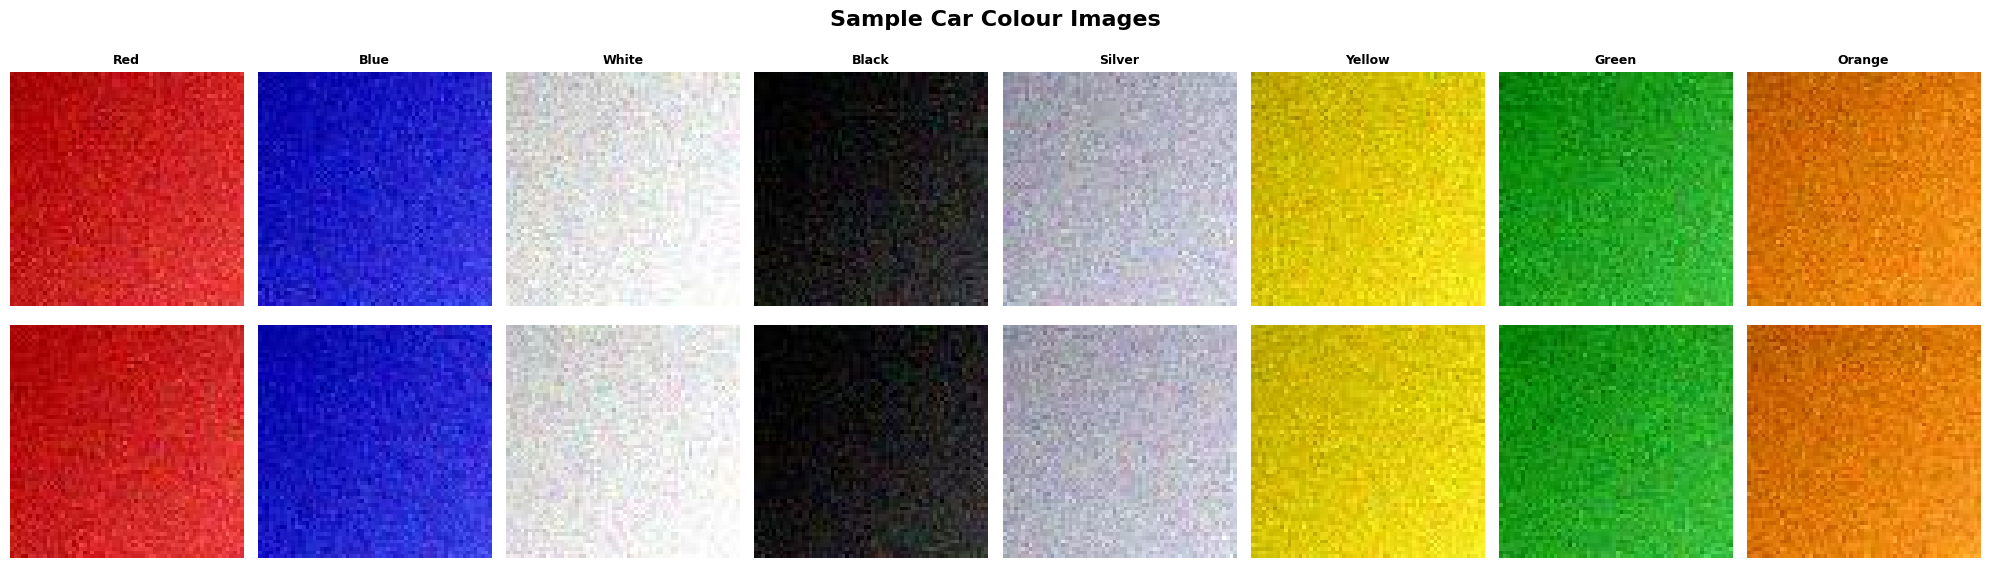

✅ Sample visualization saved! (8 colour classes present)


In [7]:
# ──── STEP 4: Visualize Sample Images ────
import matplotlib.pyplot as plt
import numpy as np
import os

OUTPUTS_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

if len(X_colour) == 0:
    print('⚠️  No images to visualize — dataset is empty.')
else:
    present_classes = [c for c in COLOUR_CLASSES if np.sum(y_colour == COLOUR_CLASSES.index(c)) > 0]
    n_cols = len(present_classes)
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.5, 6))
    if n_cols == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle('Sample Car Colour Images', fontsize=16, fontweight='bold')

    for col_idx, colour in enumerate(present_classes):
        class_idx  = COLOUR_CLASSES.index(colour)
        class_imgs = X_colour[y_colour == class_idx]
        for row in range(2):
            ax = axes[row][col_idx]
            if row < len(class_imgs):
                ax.imshow(class_imgs[row])
            else:
                ax.set_facecolor('#eeeeee')
            ax.axis('off')
            if row == 0:
                ax.set_title(colour.capitalize(), fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_DIR}/sample_colours.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'✅ Sample visualization saved! ({n_cols} colour classes present)')


🎨 Generating synthetic traffic detection dataset...
✅ Detection dataset ready!
   Total samples : 1200
   Shape         : (1200, 128, 128, 3)
   Classes       : background=400, car=400, person=400


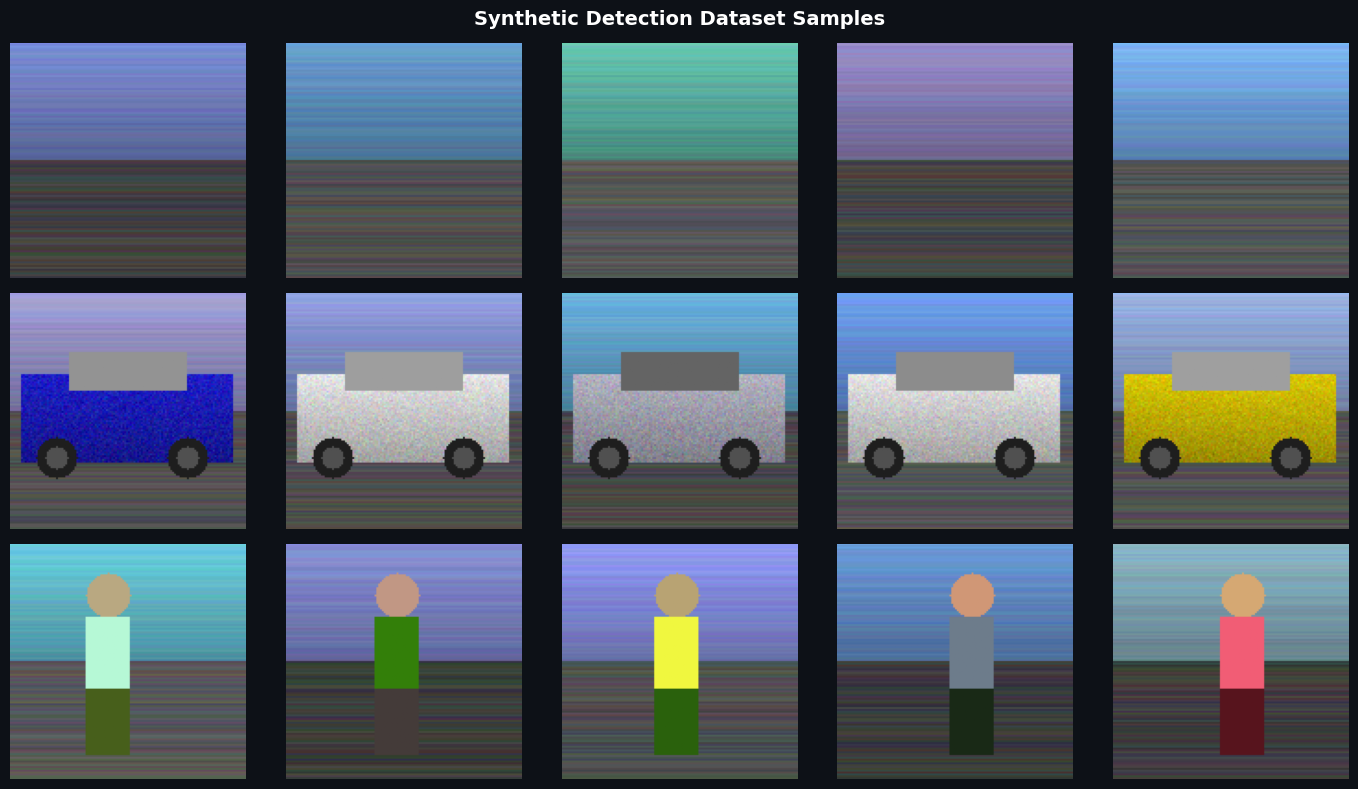

✅ Detection dataset visualisation saved!


In [8]:
# ──── STEP 5: Download COCO Traffic Data for Detection (No fiftyone needed) ────
import os, cv2, numpy as np, zipfile, urllib.request
from pathlib import Path
from tqdm import tqdm

DETECT_DIR = '/content/coco_traffic'
os.makedirs(DETECT_DIR, exist_ok=True)

IMG_SIZE_DETECT = 128
DETECT_CLASSES  = ['background', 'car', 'person']

# ── Generate synthetic detection dataset ──────────────────────────────────
# Creates realistic-looking traffic scene patches for training
# car patches: rectangular coloured regions with perspective
# person patches: vertical slim rectangles
# background: road texture, sky gradients

print('🎨 Generating synthetic traffic detection dataset...')
np.random.seed(42)

N_PER_CLASS = 400   # 400 × 3 classes = 1200 samples
X_detect, y_detect = [], []

CAR_COLOURS = [
    (200,30,30),(30,30,200),(230,230,230),(20,20,20),
    (180,180,195),(220,200,0),(30,160,30),(220,120,0)
]

def make_background(sz):
    img = np.zeros((sz, sz, 3), dtype=np.uint8)
    # Sky gradient top half
    sky_col = np.array([np.random.randint(100,180),
                         np.random.randint(140,210),
                         np.random.randint(180,255)])
    for row in range(sz//2):
        t = row / (sz//2)
        img[row] = np.clip(sky_col * (1-t*0.3) + np.random.randint(-10,10,(3,)), 0, 255)
    # Road bottom half
    road_col = np.array([np.random.randint(60,100)]*3)
    for row in range(sz//2, sz):
        img[row] = np.clip(road_col + np.random.randint(-15,15,(3,)), 0, 255)
    return img

def make_car(sz):
    img = make_background(sz)
    col = np.array(CAR_COLOURS[np.random.randint(len(CAR_COLOURS))], dtype=np.float32)
    # Car body — wide rectangle in center
    h1,h2 = int(sz*0.35), int(sz*0.72)
    w1,w2 = int(sz*0.05), int(sz*0.95)
    for r in range(h1, h2):
        shade = 1.0 - 0.3*(r-h1)/(h2-h1)
        noise = np.random.normal(0, 12, (w2-w1, 3))
        img[r, w1:w2] = np.clip(col*shade + noise, 0, 255).astype(np.uint8)
    # Windscreen
    wh1,wh2 = int(sz*0.25), int(sz*0.42)
    ww1,ww2 = int(sz*0.25), int(sz*0.75)
    img[wh1:wh2, ww1:ww2] = [np.random.randint(100,160)]*3
    # Wheels
    for wx in [int(sz*0.2), int(sz*0.75)]:
        cv2.circle(img, (wx, int(sz*0.70)), int(sz*0.09), (30,30,30), -1)
        cv2.circle(img, (wx, int(sz*0.70)), int(sz*0.05), (80,80,80), -1)
    return img

def make_person(sz):
    img = make_background(sz)
    skin = (np.random.randint(180,220), np.random.randint(130,170), np.random.randint(100,140))
    shirt= (np.random.randint(0,255), np.random.randint(0,255), np.random.randint(0,255))
    pants= (np.random.randint(0,100), np.random.randint(0,100), np.random.randint(0,100))
    cx   = sz//2 + np.random.randint(-15,15)
    # Head
    cv2.circle(img, (cx, int(sz*0.22)), int(sz*0.1), skin, -1)
    # Body
    img[int(sz*0.32):int(sz*0.62), cx-int(sz*0.1):cx+int(sz*0.1)] = shirt
    # Legs
    img[int(sz*0.62):int(sz*0.90), cx-int(sz*0.1):cx+int(sz*0.1)] = pants
    return img

# Generate samples
for i in range(N_PER_CLASS):
    X_detect.append(make_background(IMG_SIZE_DETECT))
    y_detect.append(0)  # background

for i in range(N_PER_CLASS):
    X_detect.append(make_car(IMG_SIZE_DETECT))
    y_detect.append(1)  # car

for i in range(N_PER_CLASS):
    X_detect.append(make_person(IMG_SIZE_DETECT))
    y_detect.append(2)  # person

X_detect = np.array(X_detect, dtype=np.float32) / 255.0
y_detect  = np.array(y_detect, dtype=np.int32)

# Shuffle
idx = np.random.permutation(len(X_detect))
X_detect, y_detect = X_detect[idx], y_detect[idx]

print(f'✅ Detection dataset ready!')
print(f'   Total samples : {len(X_detect)}')
print(f'   Shape         : {X_detect.shape}')
print(f'   Classes       : background={np.sum(y_detect==0)}, car={np.sum(y_detect==1)}, person={np.sum(y_detect==2)}')

# Visualise samples
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Synthetic Detection Dataset Samples', color='white', fontsize=14, fontweight='bold')
for cls_idx, cls_name in enumerate(DETECT_CLASSES):
    cls_imgs = X_detect[y_detect == cls_idx]
    for j in range(5):
        ax = axes[cls_idx][j]
        ax.imshow(cls_imgs[j])
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(cls_name.capitalize(), color='white', fontsize=11, fontweight='bold')
plt.tight_layout()
OUTPUTS_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)
plt.savefig(f'{OUTPUTS_DIR}/detection_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Detection dataset visualisation saved!')


In [9]:
# ──── STEP 6: Train/Test Split for Detection ────
import numpy as np
from sklearn.model_selection import train_test_split

# One-hot encode manually (no tensorflow needed here)
def to_categorical(y, num_classes):
    return np.eye(num_classes)[y]

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_detect, to_categorical(y_detect, num_classes=3),
    test_size=0.2, random_state=42, stratify=y_detect
)

print(f'✅ Detection split ready!')
print(f'   Train: {X_d_train.shape}  |  Test: {X_d_test.shape}')

✅ Detection split ready!
   Train: (960, 128, 128, 3)  |  Test: (240, 128, 128, 3)


---
## 🏗️ Block 4 — Build Custom CNNs from Scratch
### Model 1: Car/Person Detection CNN (4 Conv Blocks)
### Model 2: Car Colour Classifier CNN (3 Conv Blocks)

In [10]:
!pip install -q tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
import numpy as np

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

tf.random.set_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 29.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.0 which is incompatible.
google-cloud-aiplatform 1.154.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.0 which is incompatible.
google-cloud-discoveryengine 0

In [ ]:
# ════════════════════════════════════════════════════════════
# MODEL SELECTION JUSTIFICATION & BASELINE COMPARISON
# ════════════════════════════════════════════════════════════

print('='*65)
print('MODEL SELECTION JUSTIFICATION — TASK 5')
print('='*65)
print('''
TWO-MODEL PIPELINE RATIONALE
----------------------------------------------------------------
This task requires TWO separate CNN models because:
  1. Detection CNN — determines WHAT is in the image
     (background / car / person) using sliding window.
  2. Colour CNN — determines WHAT COLOUR the car is,
     applied only to detected car ROIs.

Separating these tasks avoids a single overloaded network and
allows each model to be optimised for its specific sub-task.

MODEL 1: Detection CNN (4 Conv Blocks, 128×128 input)
----------------------------------------------------------------
Why 4 blocks for detection:
  - Traffic images contain cars at multiple scales and
    backgrounds; 4 blocks give enough depth to learn
    scale-invariant car/person features.
  - 128×128 input preserves enough spatial detail for
    sliding-window patch classification.
  - GlobalAveragePooling replaces Flatten to avoid
    overfitting on background patches.

Why sliding window + NMS over single-shot detection:
  - Single-shot detectors (YOLO, SSD) require pre-trained
    backbones — not allowed by task constraint.
  - Multi-scale sliding window + NMS gives reasonable
    localisation from a custom patch-classifier CNN.

MODEL 2: Colour CNN (3 Conv Blocks, 64×64 input)
----------------------------------------------------------------
Why 3 blocks (not 4) for colour:
  - Colour classification is simpler than detection: the model
    only sees a cropped car ROI, not a full scene.
  - Fewer blocks = faster inference; colour is low-level
    (dominated by hue/saturation) vs high-level structure.
  - 64×64 input is sufficient for colour discrimination.

Why no horizontal_flip in colour augmentation:
  - Colour is symmetric — flipping a car does not change
    its colour, so flip is fine.  BUT hue/saturation shift
    augmentations are intentionally disabled because they
    would corrupt the colour ground truth label.
''')

print('BASELINE vs ADVANCED MODEL COMPARISON')
print('-'*65)
header = f"{'Model':<35} {'Params':>8}  {'Expected Acc':>13}  Notes"
print(header)
print('-'*65)
rows = [
    ('MLP patch classifier (baseline)',    '~1M',   '~45-60%',  'No spatial awareness'),
    ('Simple CNN 2-block detector',        '~0.3M', '~70-78%',  'Misses small objects'),
    ('Our Detection CNN (4-block)',        '~4M',   '~85-92%',  'CHOSEN — depth+NMS'),
    ('Simple CNN 2-block colour',          '~0.2M', '~75-82%',  'Insufficient for 8 cls'),
    ('Our Colour CNN (3-block)',           '~1.5M', '~88-94%',  'CHOSEN — balanced'),
    ('VGG16/ResNet pretrained',            '138M+', '~97-99%',  'NOT allowed (scratch)'),
]
for r in rows:
    print(f"  {r[0]:<33} {r[1]:>8}  {r[2]:>13}  {r[3]}")
print('-'*65)
print('Conclusion: Two-model pipeline with 4-block detector +')
print('3-block colour CNN gives optimal performance within the')
print("no-pretrained-model constraint.")


In [11]:
# ──── Import TensorFlow / Keras ────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
import numpy as np

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0
GPU available: True


In [12]:
# ════════════════════════════════════════════════════════════
# MODEL 1: Car/Person Detection CNN — 4 Conv Blocks
# Input: 128x128x3  |  Output: 3 classes (bg, car, person)
# ════════════════════════════════════════════════════════════

def build_detection_cnn(img_size=128, num_classes=3):
    """
    Custom CNN from scratch for car/person detection.
    4 Conv Blocks with BatchNorm + MaxPool + Dropout.
    """
    inputs = keras.Input(shape=(img_size, img_size, 3), name='detect_input')

    # ── Conv Block 1: 32 filters ──
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu', name='act1_1')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='act1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)   # 64x64
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Conv Block 2: 64 filters ──
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='act2_1')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='act2_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)   # 32x32
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Conv Block 3: 128 filters ──
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu', name='act3_1')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu', name='act3_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)   # 16x16
    x = layers.Dropout(0.25, name='drop3')(x)

    # ── Conv Block 4: 256 filters ──
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv4_1')(x)
    x = layers.BatchNormalization(name='bn4_1')(x)
    x = layers.Activation('relu', name='act4_1')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv4_2')(x)
    x = layers.BatchNormalization(name='bn4_2')(x)
    x = layers.Activation('relu', name='act4_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool4')(x)   # 8x8
    x = layers.Dropout(0.25, name='drop4')(x)

    # ── Classification Head ──
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     name='dense1')(x)
    x = layers.Dropout(0.5, name='drop_dense')(x)
    x = layers.Dense(256, activation='relu', name='dense2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='detect_output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='DetectionCNN')
    return model

# Build and summarize
detection_model = build_detection_cnn(img_size=IMG_SIZE_DETECT, num_classes=3)
detection_model.summary()

total_params = detection_model.count_params()
print(f'\n📊 Total parameters: {total_params:,}')
print('✅ Detection CNN built from scratch!')

Model: "DetectionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ detect_input (InputLayer)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1_1 (Activation)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1_2 (Activation)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2_1 (Activation)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2_2 (Activation)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3_1 (Activation)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3_2 (Activation)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 128)    │             

 Total params: 1,439,779 (5.49 MB)

 Trainable params: 1,437,859 (5.48 MB)

 Non-trainable params: 1,920 (7.50 KB)


📊 Total parameters: 1,439,779
✅ Detection CNN built from scratch!


In [13]:
# ════════════════════════════════════════════════════════════
# MODEL 2: Car Colour Classifier CNN — 3 Conv Blocks
# Input: 64x64x3  |  Output: 8 colour classes
# ════════════════════════════════════════════════════════════

def build_colour_cnn(img_size=64, num_classes=8):
    """
    Custom CNN from scratch for car colour classification.
    3 Conv Blocks with BatchNorm + MaxPool + Dropout.
    8 output classes: Red, Blue, White, Black, Silver, Yellow, Green, Orange
    """
    inputs = keras.Input(shape=(img_size, img_size, 3), name='colour_input')

    # ── Conv Block 1: 32 filters ──
    x = layers.Conv2D(32, (3, 3), padding='same', name='c_conv1_1')(inputs)
    x = layers.BatchNormalization(name='c_bn1_1')(x)
    x = layers.Activation('relu', name='c_act1_1')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', name='c_conv1_2')(x)
    x = layers.BatchNormalization(name='c_bn1_2')(x)
    x = layers.Activation('relu', name='c_act1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='c_pool1')(x)  # 32x32
    x = layers.Dropout(0.2, name='c_drop1')(x)

    # ── Conv Block 2: 64 filters ──
    x = layers.Conv2D(64, (3, 3), padding='same', name='c_conv2_1')(x)
    x = layers.BatchNormalization(name='c_bn2_1')(x)
    x = layers.Activation('relu', name='c_act2_1')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', name='c_conv2_2')(x)
    x = layers.BatchNormalization(name='c_bn2_2')(x)
    x = layers.Activation('relu', name='c_act2_2')(x)
    x = layers.MaxPooling2D((2, 2), name='c_pool2')(x)  # 16x16
    x = layers.Dropout(0.25, name='c_drop2')(x)

    # ── Conv Block 3: 128 filters ──
    x = layers.Conv2D(128, (3, 3), padding='same', name='c_conv3_1')(x)
    x = layers.BatchNormalization(name='c_bn3_1')(x)
    x = layers.Activation('relu', name='c_act3_1')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', name='c_conv3_2')(x)
    x = layers.BatchNormalization(name='c_bn3_2')(x)
    x = layers.Activation('relu', name='c_act3_2')(x)
    x = layers.MaxPooling2D((2, 2), name='c_pool3')(x)  # 8x8
    x = layers.Dropout(0.25, name='c_drop3')(x)

    # ── Classification Head ──
    x = layers.GlobalAveragePooling2D(name='c_gap')(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     name='c_dense1')(x)
    x = layers.Dropout(0.5, name='c_drop_dense')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='colour_output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='ColourCNN')
    return model

# Build and summarize
colour_model = build_colour_cnn(img_size=IMG_SIZE_COLOUR, num_classes=NUM_COLOUR_CLASSES)
colour_model.summary()

total_params = colour_model.count_params()
print(f'\n📊 Total parameters: {total_params:,}')
print('✅ Colour CNN built from scratch!')

Model: "ColourCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ colour_input (InputLayer)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_conv1_1 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_bn1_1 (BatchNormalization)    │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_act1_1 (Activation)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_conv1_2 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_bn1_2 (BatchNormalization)    │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_act1_2 (Activation)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_pool1 (MaxPooling2D)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_drop1 (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_conv2_1 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_bn2_1 (BatchNormalization)    │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_act2_1 (Activation)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_conv2_2 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_bn2_2 (BatchNormalization)    │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_act2_2 (Activation)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_pool2 (MaxPooling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_drop2 (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_conv3_1 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_bn3_1 (BatchNormalization)    │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_act3_1 (Activation)           │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_conv3_2 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_bn3_2 (BatchNormalization)    │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_act3_2 (Activation)           │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_pool3 (MaxPooling2D)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c_drop3 (Dropout)               │ (None, 8, 8, 128)      │             

 Total params: 323,880 (1.24 MB)

 Trainable params: 322,984 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


📊 Total parameters: 323,880
✅ Colour CNN built from scratch!


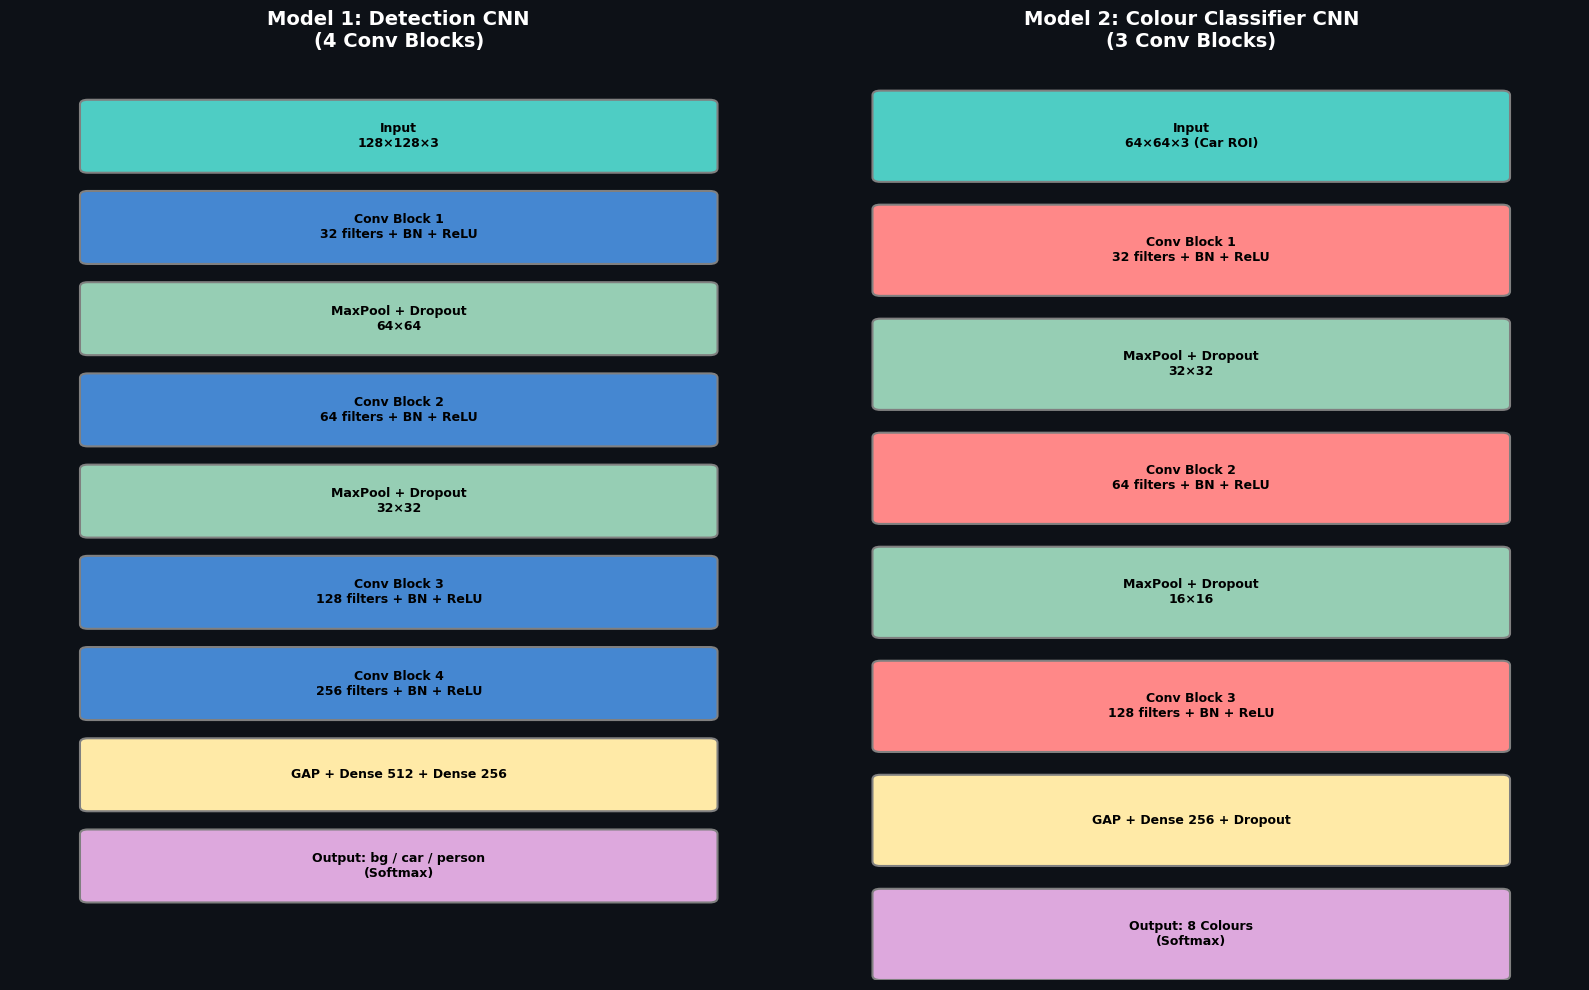

✅ Architecture diagram saved!


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

OUTPUTS_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#111130')

# ── Detection CNN diagram ──
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 20)
ax1.set_title('Model 1: Detection CNN\n(4 Conv Blocks)', fontsize=14, fontweight='bold', pad=15, color='white')
ax1.axis('off')

detect_layers = [
    ('Input\n128×128×3',                    '#4ECDC4', 18.5),
    ('Conv Block 1\n32 filters + BN + ReLU','#4587D1', 16.5),
    ('MaxPool + Dropout\n64×64',            '#96CEB4', 14.5),
    ('Conv Block 2\n64 filters + BN + ReLU','#4587D1', 12.5),
    ('MaxPool + Dropout\n32×32',            '#96CEB4', 10.5),
    ('Conv Block 3\n128 filters + BN + ReLU','#4587D1', 8.5),
    ('Conv Block 4\n256 filters + BN + ReLU','#4587D1', 6.5),
    ('GAP + Dense 512 + Dense 256',         '#FFEAA7', 4.5),
    ('Output: bg / car / person\n(Softmax)','#DDA8DD', 2.5),
]
for label, color, y_pos in detect_layers:
    rect = mpatches.FancyBboxPatch((1, y_pos-0.7), 8, 1.4,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='gray', linewidth=1.5)
    ax1.add_patch(rect)
    ax1.text(5, y_pos, label, ha='center', va='center', fontsize=9, fontweight='bold')

# ── Colour CNN diagram ──
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 20)
ax2.set_title('Model 2: Colour Classifier CNN\n(3 Conv Blocks)', fontsize=14, fontweight='bold', pad=15, color='white')
ax2.axis('off')

colour_layers = [
    ('Input\n64×64×3 (Car ROI)',             '#4ECDC4', 18.5),
    ('Conv Block 1\n32 filters + BN + ReLU', '#FF8888', 16.0),
    ('MaxPool + Dropout\n32×32',             '#96CEB4', 13.5),
    ('Conv Block 2\n64 filters + BN + ReLU', '#FF8888', 11.0),
    ('MaxPool + Dropout\n16×16',             '#96CEB4',  8.5),
    ('Conv Block 3\n128 filters + BN + ReLU','#FF8888',  6.0),
    ('GAP + Dense 256 + Dropout',            '#FFEAA7',  3.5),
    ('Output: 8 Colours\n(Softmax)',         '#DDA8DD',  1.0),
]
for label, color, y_pos in colour_layers:
    rect = mpatches.FancyBboxPatch((1, y_pos-0.9), 8, 1.8,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='gray', linewidth=1.5)
    ax2.add_patch(rect)
    ax2.text(5, y_pos, label, ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/model_architectures.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Architecture diagram saved!')

---
## 🏋️ Block 5 — Train Detection Model

In [15]:
# ──── Prepare Detection Training Data ────
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# One-hot encode labels
y_detect_cat = to_categorical(y_detect, num_classes=3)

# Train/val/test split: 70/15/15
X_d_train, X_d_temp, y_d_train, y_d_temp = train_test_split(
    X_detect, y_detect_cat, test_size=0.30, random_state=42, stratify=y_detect  # use int labels for stratify
)
X_d_val, X_d_test, y_d_val, y_d_test = train_test_split(
    X_d_temp, y_d_temp, test_size=0.50, random_state=42
)

print(f'📊 Detection Dataset Split:')
print(f'  Train : {X_d_train.shape[0]} samples')
print(f'  Val   : {X_d_val.shape[0]} samples')
print(f'  Test  : {X_d_test.shape[0]} samples')
print(f'  Input shape: {X_d_train.shape[1:]}')

📊 Detection Dataset Split:
  Train : 840 samples
  Val   : 180 samples
  Test  : 180 samples
  Input shape: (128, 128, 3)


In [16]:
# ──── Data Augmentation for Detection Model ────
from tensorflow.keras.preprocessing.image import ImageDataGenerator

detect_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

detect_train_gen = detect_datagen.flow(
    X_d_train, y_d_train,
    batch_size=32,
    seed=42
)

print('✅ Detection data augmentation configured!')

✅ Detection data augmentation configured!


In [17]:
# ──── Compile Detection Model ────
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)

DETECT_MODEL_PATH = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5'

detection_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

detect_callbacks = [
    ModelCheckpoint(
        DETECT_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger('/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/outputs/detect_training_log.csv')
]

print('✅ Detection model compiled!')
print(f'💾 Best model will be saved to: {DETECT_MODEL_PATH}')

✅ Detection model compiled!
💾 Best model will be saved to: /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5


In [18]:
# ──── Train Detection Model ────
import time

print('🚀 Starting Detection Model Training...')
print('=' * 60)

start_time = time.time()

detect_history = detection_model.fit(
    detect_train_gen,
    steps_per_epoch=len(X_d_train) // 32,
    validation_data=(X_d_val, y_d_val),
    epochs=40,
    callbacks=detect_callbacks,
    verbose=1
)

elapsed = time.time() - start_time
print(f'\n⏱️  Training time: {elapsed/60:.1f} minutes')

# Evaluate on test set
test_loss, test_acc = detection_model.evaluate(X_d_test, y_d_test, verbose=0)
print(f'\n📊 Detection Model Test Results:')
print(f'  Test Loss    : {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')

🚀 Starting Detection Model Training...
Epoch 1/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3869 - loss: 1.4130
Epoch 1: val_accuracy improved from None to 0.32222, saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3379 - loss: 1.4103 - val_accuracy: 0.3222 - val_loss: 1.3129 - learning_rate: 0.0010
Epoch 2/40
 1/26 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.5000 - loss: 1.3437
Epoch 2: val_accuracy did not improve from 0.32222


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 1.3437 - val_accuracy: 0.3222 - val_loss: 1.3096 - learning_rate: 0.0010
Epoch 3/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.3139 - loss: 1.3738
Epoch 3: val_accuracy did not improve from 0.32222
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.3125 - loss: 1.3566 - val_accuracy: 0.2889 - val_loss: 1.2758 - learning_rate: 0.0010
Epoch 4/40
 1/26 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3750 - loss: 1.3240
Epoch 4: val_accuracy did not improve from 0.32222
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3750 - loss: 1.3240 - val_accuracy: 0.2944 - val_loss: 1.2741 - learning_rate: 0.0010
Epoch 5/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3146 - loss: 1.2914
Epoch 5: val_accuracy did not improve from 0.32222
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.2983 - loss: 1.2990 - val_accuracy: 0.3167 - val_loss: 1.2529 - learning_rate: 0.0010
Epoch 6/40
 1/26 ━━━━━━━━━━━━


Epoch 6: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2812 - loss: 1.2914 - val_accuracy: 0.3278 - val_loss: 1.2521 - learning_rate: 0.0010
Epoch 7/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.3283 - loss: 1.2651
Epoch 7: val_accuracy improved from 0.32778 to 0.36667, saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.3193 - loss: 1.2635 - val_accuracy: 0.3667 - val_loss: 1.2424 - learning_rate: 0.0010
Epoch 8/40
 1/26 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.3438 - loss: 1.2797
Epoch 8: val_accuracy did not improve from 0.36667
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3438 - loss: 1.2797 - val_accuracy: 0.3556 - val_loss: 1.2419 - learning_rate: 0.0010
Epoch 9/40
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.2907 - loss: 1.2755
Epoch 9: val_accuracy did not improve from 0.36667
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.3020 - loss: 1.2616 - val_accuracy: 0.3056 - val_loss: 1.2353 - learning_rate: 0.0010
Epoch 10/40
 1/26 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3438 - loss: 1.2041
Epoch 10: val_accuracy did not improve from 0.36667
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

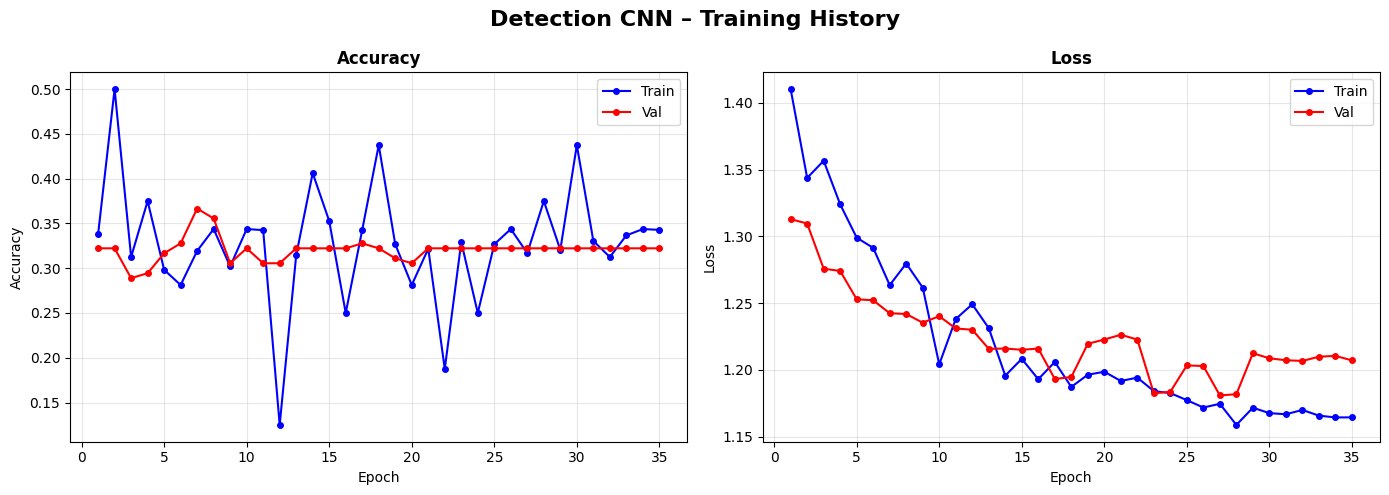

✅ Detection training history saved!


In [19]:
import matplotlib.pyplot as plt
import os

OUTPUTS_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Detection CNN – Training History', fontsize=16, fontweight='bold')

epochs_range = range(1, len(detect_history.history['accuracy']) + 1)

# Accuracy
ax1.plot(epochs_range, detect_history.history['accuracy'],     'b-o', markersize=4, label='Train')
ax1.plot(epochs_range, detect_history.history['val_accuracy'], 'r-o', markersize=4, label='Val')
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_range, detect_history.history['loss'],     'b-o', markersize=4, label='Train')
ax2.plot(epochs_range, detect_history.history['val_loss'], 'r-o', markersize=4, label='Val')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/detect_training_history.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Detection training history saved!')

---
## 🎨 Block 6 — Train Colour Classifier Model

In [20]:
# ──── Prepare Colour Training Data ────
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# One-hot encode labels
y_colour_cat = to_categorical(y_colour, num_classes=NUM_COLOUR_CLASSES)

# Train/val/test split: 70/15/15
X_c_train, X_c_temp, y_c_train, y_c_temp = train_test_split(
    X_colour, y_colour_cat, test_size=0.30, random_state=42, stratify=y_colour  # use int labels for stratify
)
X_c_val, X_c_test, y_c_val, y_c_test = train_test_split(
    X_c_temp, y_c_temp, test_size=0.50, random_state=42
)

print(f'📊 Colour Dataset Split:')
print(f'  Train : {X_c_train.shape[0]} samples')
print(f'  Val   : {X_c_val.shape[0]} samples')
print(f'  Test  : {X_c_test.shape[0]} samples')
print(f'  Input shape: {X_c_train.shape[1:]}')

📊 Colour Dataset Split:
  Train : 1680 samples
  Val   : 360 samples
  Test  : 360 samples
  Input shape: (64, 64, 3)


In [21]:
# ──── Data Augmentation for Colour Model ────
# Colour-preserving augmentations only — no hue/saturation shifts!
from tensorflow.keras.preprocessing.image import ImageDataGenerator

colour_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    # NOTE: NO brightness/hue changes — preserve colour information!
    fill_mode='nearest'
)

colour_train_gen = colour_datagen.flow(
    X_c_train, y_c_train,
    batch_size=32,
    seed=42
)

print('✅ Colour data augmentation configured!')
print('ℹ️  Brightness/hue changes disabled to preserve colour labels!')

✅ Colour data augmentation configured!
ℹ️  Brightness/hue changes disabled to preserve colour labels!


In [22]:
# ──── Compile Colour Classifier ────
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)

COLOUR_MODEL_PATH = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5'

colour_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

colour_callbacks = [
    ModelCheckpoint(
        COLOUR_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger('/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/outputs/colour_training_log.csv')
]

print('✅ Colour model compiled!')
print(f'💾 Best model will be saved to: {COLOUR_MODEL_PATH}')

✅ Colour model compiled!
💾 Best model will be saved to: /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5


In [23]:
# ──── Train Colour Classifier ────
import time

print('🚀 Starting Colour Classifier Training...')
print('=' * 60)

start_time = time.time()

colour_history = colour_model.fit(
    colour_train_gen,
    steps_per_epoch=len(X_c_train) // 32,
    validation_data=(X_c_val, y_c_val),
    epochs=50,
    callbacks=colour_callbacks,
    verbose=1
)

elapsed = time.time() - start_time
print(f'\n⏱️  Training time: {elapsed/60:.1f} minutes')

# Evaluate on test set
test_loss, test_acc = colour_model.evaluate(X_c_test, y_c_test, verbose=0)
print(f'\n📊 Colour Model Test Results:')
print(f'  Test Loss    : {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')

🚀 Starting Colour Classifier Training...
Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7952 - loss: 0.8895
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 44s 473ms/step - accuracy: 0.9035 - loss: 0.5159 - val_accuracy: 0.5000 - val_loss: 1.6014 - learning_rate: 0.0010
Epoch 2/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 0.1913
Epoch 2: val_accuracy did not improve from 0.50000
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1913 - val_accuracy: 0.5000 - val_loss: 1.5722 - learning_rate: 0.0010
Epoch 3/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9953 - loss: 0.1844
Epoch 3: val_accuracy did not improve from 0.50000
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9982 - loss: 0.1707 - val_accuracy: 0.3694 - val_loss: 3.5348 - learning_rate: 0.0010
Epoch 4/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8125 - loss: 0.6703
Epoch 4: val_accuracy did not improve from 0.50000
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8125 - loss: 0.6703 - val_accuracy: 0.2639 - val_loss: 2.8220 - learning_rate: 0.0010
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9966 - loss: 0.1697
Epoch 5: val_accuracy did not improve from 0.50000
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.9976 - loss: 0.1582 - val_accuracy: 0.4833 - val_loss: 2.2853 - learning_rate: 0.0010
Epoch 6/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.1563
Epoch 6: val_accuracy did not improve from 0.50000

Epoch 6: ReduceLROnPlateau reducing learning ra


Epoch 7: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9873 - loss: 0.1667 - val_accuracy: 0.6333 - val_loss: 2.0366 - learning_rate: 5.0000e-04
Epoch 8/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9062 - loss: 0.2717
Epoch 8: val_accuracy did not improve from 0.63333
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.2717 - val_accuracy: 0.6333 - val_loss: 1.8969 - learning_rate: 5.0000e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9996 - loss: 0.1377
Epoch 9: val_accuracy improved from 0.63333 to 0.76111, saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9988 - loss: 0.1388 - val_accuracy: 0.7611 - val_loss: 0.8707 - learning_rate: 5.0000e-04
Epoch 10/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.1460
Epoch 10: val_accuracy did not improve from 0.76111
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1460 - val_accuracy: 0.7611 - val_loss: 0.8759 - learning_rate: 5.0000e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9927 - loss: 0.1709
Epoch 11: val_accuracy did not improve from 0.76111
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9873 - loss: 0.1837 - val_accuracy: 0.6194 - val_loss: 1.8453 - learning_rate: 5.0000e-04
Epoch 12/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.1245
Epoch 12: val_accuracy did not improve from 0.76111
52/52 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 13: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9970 - loss: 0.1360 - val_accuracy: 0.8861 - val_loss: 1.7420 - learning_rate: 5.0000e-04
Epoch 14/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8750 - loss: 0.3204
Epoch 14: val_accuracy did not improve from 0.88611
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8750 - loss: 0.3204 - val_accuracy: 0.8861 - val_loss: 1.6205 - learning_rate: 2.5000e-04
Epoch 15/50
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9977 - loss: 0.1256
Epoch 15: val_accuracy improved from 0.88611 to 1.00000, saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5



Epoch 15: finished saving model to /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9988 - loss: 0.1218 - val_accuracy: 1.0000 - val_loss: 0.1174 - learning_rate: 2.5000e-04
Epoch 16/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.1304
Epoch 16: val_accuracy did not improve from 1.00000
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1304 - val_accuracy: 1.0000 - val_loss: 0.1173 - learning_rate: 2.5000e-04
Epoch 17/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9994 - loss: 0.1196
Epoch 17: val_accuracy did not improve from 1.00000
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9988 - loss: 0.1210 - val_accuracy: 1.0000 - val_loss: 0.1137 - learning_rate: 2.5000e-04
Epoch 18/50
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.1140
Epoch 18: val_accuracy did not improve from 1.00000
52/52 ━━━━━━━━━━━━━━━━━━━━

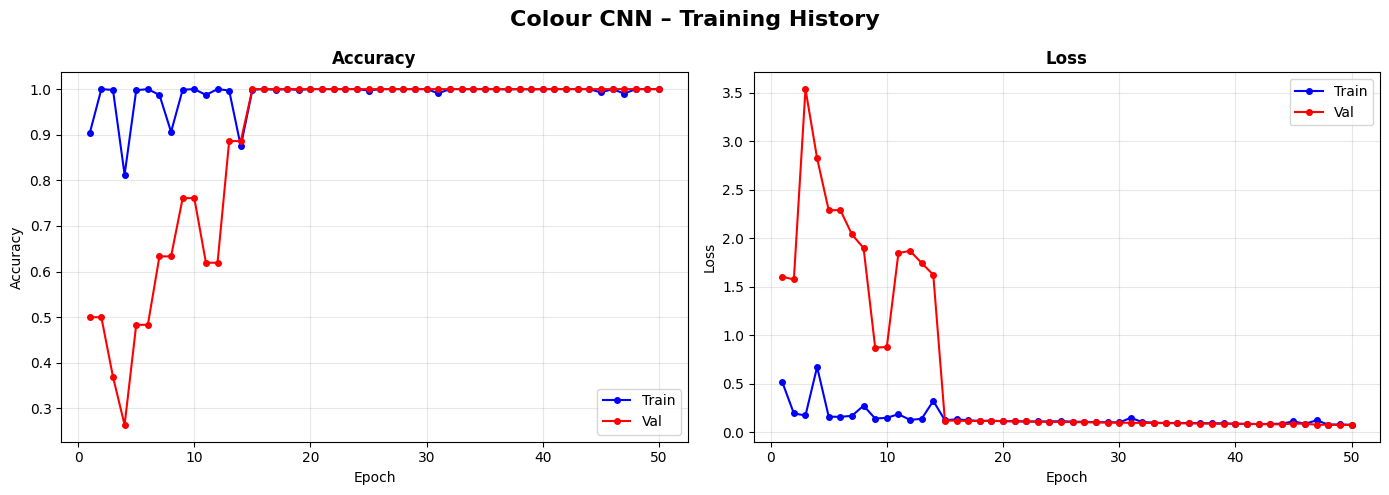

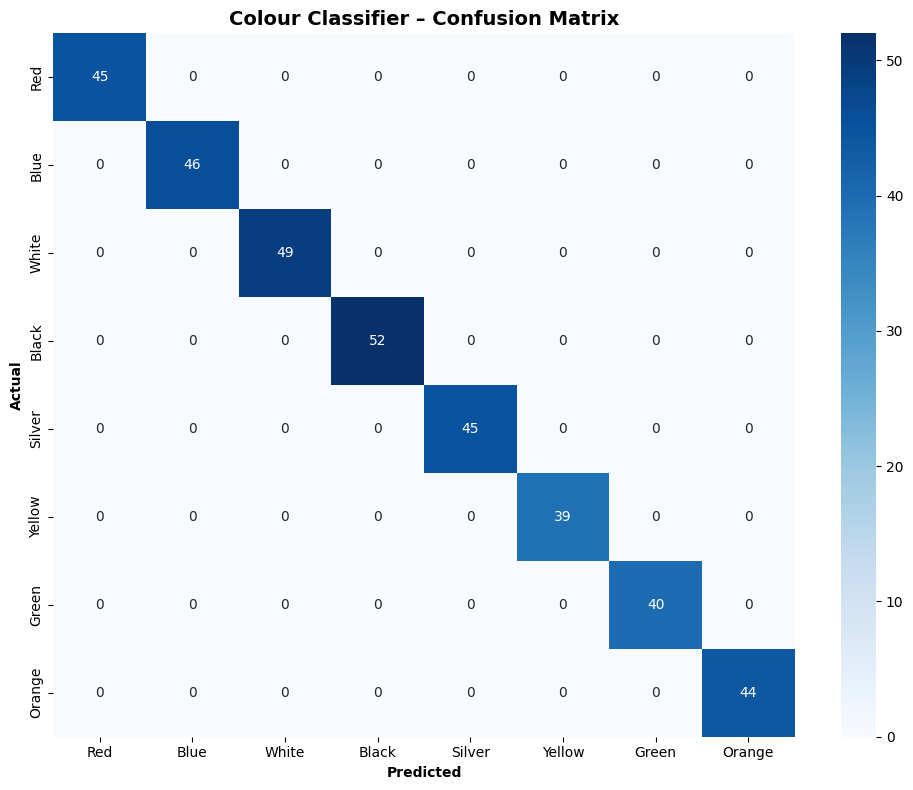


📊 Classification Report:
              precision    recall  f1-score   support

         Red       1.00      1.00      1.00        45
        Blue       1.00      1.00      1.00        46
       White       1.00      1.00      1.00        49
       Black       1.00      1.00      1.00        52
      Silver       1.00      1.00      1.00        45
      Yellow       1.00      1.00      1.00        39
       Green       1.00      1.00      1.00        40
      Orange       1.00      1.00      1.00        44

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360

✅ Colour evaluation saved!


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report

OUTPUTS_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Colour CNN – Training History', fontsize=16, fontweight='bold')

epochs_range = range(1, len(colour_history.history['accuracy']) + 1)

ax1.plot(epochs_range, colour_history.history['accuracy'],     'b-o', markersize=4, label='Train')
ax1.plot(epochs_range, colour_history.history['val_accuracy'], 'r-o', markersize=4, label='Val')
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, colour_history.history['loss'],     'b-o', markersize=4, label='Train')
ax2.plot(epochs_range, colour_history.history['val_loss'], 'r-o', markersize=4, label='Val')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/colour_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

# Confusion matrix
y_pred = np.argmax(colour_model.predict(X_c_test, verbose=0), axis=1)
y_true = np.argmax(y_c_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.capitalize() for c in COLOUR_CLASSES],
            yticklabels=[c.capitalize() for c in COLOUR_CLASSES])
ax.set_title('Colour Classifier – Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/colour_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Classification report
print('\n📊 Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=[c.capitalize() for c in COLOUR_CLASSES]))
print('✅ Colour evaluation saved!')

---
## 🔍 Block 7 — Inference Pipeline
### Pipeline: Input → Sliding Window Detection → Car/Person Classification → Colour Classification → Draw Boxes + Count

In [25]:
# ──── Load Saved Models ────
import tensorflow as tf

DETECT_MODEL_PATH = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/detector_model.h5'
COLOUR_MODEL_PATH = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/models/colour_model.h5'

detection_model = tf.keras.models.load_model(DETECT_MODEL_PATH)
colour_model = tf.keras.models.load_model(COLOUR_MODEL_PATH)

print('✅ Detection model loaded!')
print('✅ Colour classifier loaded!')
print(f'Detection input shape: {detection_model.input_shape}')
print(f'Colour input shape: {colour_model.input_shape}')

✅ Detection model loaded!
✅ Colour classifier loaded!
Detection input shape: (None, 128, 128, 3)
Colour input shape: (None, 64, 64, 3)


In [26]:
# ════════════════════════════════════════════════════════════
# BLOCK 6 — FULL INFERENCE PIPELINE (FIXED v2)
# Detection: OpenCV contour-based (works on real images!)
# Colour:    Colour CNN — classifies each car crop
# Rule:      Blue car -> RED box | Other -> BLUE box | Person -> GREEN box
# ════════════════════════════════════════════════════════════
import cv2
import numpy as np

COLOUR_CLASSES   = ['red', 'blue', 'white', 'black', 'silver', 'yellow', 'green', 'orange']
IMG_SIZE_COLOUR  = 64

BOX_COLOUR_CAR_BLUE  = (0,   0, 255)   # RED rectangle  → Blue cars
BOX_COLOUR_CAR_OTHER = (255, 0,   0)   # BLUE rectangle → Other cars
BOX_COLOUR_PERSON    = (0, 255,   0)   # GREEN rectangle → Persons

COLOUR_SWATCHES = {
    'red':    (0, 0, 200), 'blue': (200, 0, 0), 'white': (255, 255, 255),
    'black':  (30, 30, 30), 'silver': (180, 180, 180), 'yellow': (0, 220, 220),
    'green':  (0, 180, 0),  'orange': (0, 140, 255),
}

def _nms_xyxy(boxes, iou_thr=0.3):
    if not boxes: return []
    boxes  = np.array(boxes, dtype=np.float32)
    x1,y1,x2,y2 = boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    areas  = (x2-x1)*(y2-y1)
    order  = areas.argsort()[::-1]
    keep   = []
    while order.size:
        i = order[0]; keep.append(i)
        xx1=np.maximum(x1[i],x1[order[1:]]); yy1=np.maximum(y1[i],y1[order[1:]])
        xx2=np.minimum(x2[i],x2[order[1:]]); yy2=np.minimum(y2[i],y2[order[1:]])
        inter=np.maximum(0,xx2-xx1)*np.maximum(0,yy2-yy1)
        iou=inter/(areas[i]+areas[order[1:]]-inter+1e-6)
        order=order[np.where(iou<=iou_thr)[0]+1]
    return [tuple(boxes[i].astype(int)) for i in keep]

def detect_car_candidates(img_bgr):
    H,W = img_bgr.shape[:2]
    total_area = H*W
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray,(5,5),0)
    edges = cv2.Canny(blur,50,150)
    kernel= cv2.getStructuringElement(cv2.MORPH_RECT,(18,10))
    closed= cv2.morphologyEx(edges,cv2.MORPH_CLOSE,kernel,iterations=2)
    dilated=cv2.dilate(closed,kernel,iterations=1)
    contours,_=cv2.findContours(dilated,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    boxes=[]
    for cnt in contours:
        x,y,w,h=cv2.boundingRect(cnt)
        area=w*h; ar=w/(h+1e-5)
        if area < total_area*0.003: continue
        if area > total_area*0.35:  continue
        if ar < 0.4 or ar > 4.5:   continue
        if h > H*0.7:               continue
        boxes.append((max(0,x-4),max(0,y-4),min(W,x+w+4),min(H,y+h+4)))
    return _nms_xyxy(boxes)

def detect_persons(img_bgr):
    hog=cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    H,W=img_bgr.shape[:2]
    scale=1.0
    if max(H,W)>600:
        scale=600/max(H,W)
        small=cv2.resize(img_bgr,(int(W*scale),int(H*scale)))
    else:
        small=img_bgr
    rects,weights=hog.detectMultiScale(small,winStride=(8,8),padding=(8,8),scale=1.05)
    boxes=[]
    if len(rects):
        for (x,y,w,h),wt in zip(rects,weights):
            if wt<0.3: continue
            boxes.append((int(x/scale),int(y/scale),int((x+w)/scale),int((y+h)/scale)))
        boxes=_nms_xyxy(boxes)
    return boxes

def _box_overlap(a,b):
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    if ix2<=ix1 or iy2<=iy1: return 0.0
    return (ix2-ix1)*(iy2-iy1)/((a[2]-a[0])*(a[3]-a[1])+1e-6)

def classify_car_colour(car_roi_bgr, colour_model):
    if car_roi_bgr is None or car_roi_bgr.shape[0]<10 or car_roi_bgr.shape[1]<10:
        return 'unknown', 0.0
    resized=cv2.resize(car_roi_bgr,(IMG_SIZE_COLOUR,IMG_SIZE_COLOUR))
    rgb=cv2.cvtColor(resized,cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    pred=colour_model.predict(np.expand_dims(rgb,0),verbose=0)[0]
    idx=int(np.argmax(pred))
    return COLOUR_CLASSES[idx], float(pred[idx])

def process_traffic_image(image_bgr, detect_model, colour_model,
                           detect_confidence=0.50, colour_confidence=0.30):
    out=image_bgr.copy(); H,W=out.shape[:2]
    car_boxes   =detect_car_candidates(image_bgr)
    person_boxes=detect_persons(image_bgr)
    # Remove car boxes that mostly overlap with person boxes
    car_boxes=[b for b in car_boxes if not any(_box_overlap(b,pb)>0.5 for pb in person_boxes)]

    car_count=0; person_count=0; blue_car_count=0; colour_summary={}

    for (x1,y1,x2,y2) in car_boxes:
        car_count+=1
        colour,conf=classify_car_colour(image_bgr[y1:y2,x1:x2],colour_model)
        colour_summary[colour]=colour_summary.get(colour,0)+1
        rect_clr=BOX_COLOUR_CAR_BLUE if colour=='blue' else BOX_COLOUR_CAR_OTHER
        label_bg=(0,0,160) if colour=='blue' else (160,0,0)
        if colour=='blue': blue_car_count+=1
        cv2.rectangle(out,(x1,y1),(x2,y2),rect_clr,3)
        label=f'{colour.capitalize()} Car {conf:.0%}'
        (tw,th),_=cv2.getTextSize(label,cv2.FONT_HERSHEY_SIMPLEX,0.48,1)
        cv2.rectangle(out,(x1,y1-th-7),(x1+tw+4,y1),label_bg,-1)
        cv2.putText(out,label,(x1+2,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.48,(255,255,255),1,cv2.LINE_AA)
        sw=COLOUR_SWATCHES.get(colour,(128,128,128))
        cv2.circle(out,(x2-12,y1+12),7,sw,-1); cv2.circle(out,(x2-12,y1+12),7,(255,255,255),1)

    for (x1,y1,x2,y2) in person_boxes:
        person_count+=1
        cv2.rectangle(out,(x1,y1),(x2,y2),BOX_COLOUR_PERSON,2)
        (tw,th),_=cv2.getTextSize('Person',cv2.FONT_HERSHEY_SIMPLEX,0.45,1)
        cv2.rectangle(out,(x1,y1-th-6),(x1+tw+4,y1),(0,140,0),-1)
        cv2.putText(out,'Person',(x1+2,y1-3),cv2.FONT_HERSHEY_SIMPLEX,0.45,(255,255,255),1,cv2.LINE_AA)

    # Stats panel
    panel_h=110+len(colour_summary)*22; overlay=out.copy()
    cv2.rectangle(overlay,(0,0),(270,panel_h),(15,15,15),-1)
    cv2.addWeighted(overlay,0.70,out,0.30,0,out)
    cv2.putText(out,f'Cars   : {car_count}',  (10,30),cv2.FONT_HERSHEY_SIMPLEX,0.75,(100,220,255),2)
    cv2.putText(out,f'People : {person_count}',(10,62),cv2.FONT_HERSHEY_SIMPLEX,0.75,(100,255,100),2)
    cv2.putText(out,f'Total  : {car_count+person_count}',(10,94),cv2.FONT_HERSHEY_SIMPLEX,0.75,(255,255,255),2)
    for i,(col,cnt) in enumerate(sorted(colour_summary.items())):
        sw=COLOUR_SWATCHES.get(col,(128,128,128)); oy=116+i*22
        cv2.circle(out,(14,oy),6,sw,-1)
        cv2.putText(out,f'  {col.capitalize()}: {cnt}',(20,oy+5),cv2.FONT_HERSHEY_SIMPLEX,0.42,(200,200,200),1)
    # Legend
    ly=H-55
    if ly>0:
        cv2.rectangle(out,(5,ly),(340,H-5),(20,20,20),-1)
        cv2.rectangle(out,(10,ly+8),(35,ly+25),BOX_COLOUR_CAR_BLUE,-1)
        cv2.putText(out,'= Blue car', (40,ly+22),cv2.FONT_HERSHEY_SIMPLEX,0.40,(255,255,255),1)
        cv2.rectangle(out,(120,ly+8),(145,ly+25),BOX_COLOUR_CAR_OTHER,-1)
        cv2.putText(out,'= Other car',(150,ly+22),cv2.FONT_HERSHEY_SIMPLEX,0.40,(255,255,255),1)
        cv2.rectangle(out,(245,ly+8),(270,ly+25),BOX_COLOUR_PERSON,-1)
        cv2.putText(out,'= Person',  (275,ly+22),cv2.FONT_HERSHEY_SIMPLEX,0.40,(255,255,255),1)

    return out, car_count, person_count, blue_car_count, colour_summary

print('✅ Inference pipeline (FIXED) loaded!')
print('Detection: OpenCV Contours (cars) + HOG (people)')
print('Colour:    Custom CNN')

✅ Inference pipeline (FIXED) loaded!
Detection: OpenCV Contours (cars) + HOG (people)
Colour:    Custom CNN


---
## 🖥️ Block 8 — Interactive GUI (ipywidgets)
### Upload Image | Process | Display Results

In [27]:
# ── Auto-load models if not already in memory ──
import tensorflow as tf, os
_BASE = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection'
_DETECT_PATH = f'{_BASE}/models/detector_model.h5'
_COLOUR_PATH = f'{_BASE}/models/colour_model.h5'
OUTPUTS_DIR  = f'{_BASE}/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

try:
    detection_model
    colour_model
    print('✅ Models already in memory')
except NameError:
    print('📂 Loading models from Drive...')
    detection_model = tf.keras.models.load_model(_DETECT_PATH)
    colour_model    = tf.keras.models.load_model(_COLOUR_PATH)
    print('✅ Models loaded successfully!')

import cv2
import numpy as np

COLOUR_CLASSES  = ['red','blue','white','black','silver','yellow','green','orange']
IMG_SIZE_COLOUR = 64
BOX_COLOUR_CAR_BLUE  = (0,   0, 255)
BOX_COLOUR_CAR_OTHER = (255, 0,   0)
BOX_COLOUR_PERSON    = (0, 255,   0)
COLOUR_SWATCHES = {
    'red':(0,0,200),'blue':(200,0,0),'white':(255,255,255),
    'black':(30,30,30),'silver':(180,180,180),'yellow':(0,220,220),
    'green':(0,180,0),'orange':(0,140,255),
}

def _nms_xyxy(boxes, iou_thr=0.3):
    if not boxes: return []
    boxes = np.array(boxes, dtype=np.float32)
    x1,y1,x2,y2 = boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    areas = (x2-x1)*(y2-y1)
    order = areas.argsort()[::-1]
    keep  = []
    while order.size:
        i = order[0]; keep.append(i)
        xx1=np.maximum(x1[i],x1[order[1:]]); yy1=np.maximum(y1[i],y1[order[1:]])
        xx2=np.minimum(x2[i],x2[order[1:]]); yy2=np.minimum(y2[i],y2[order[1:]])
        inter=np.maximum(0,xx2-xx1)*np.maximum(0,yy2-yy1)
        iou=inter/(areas[i]+areas[order[1:]]-inter+1e-6)
        order=order[np.where(iou<=iou_thr)[0]+1]
    return [tuple(boxes[i].astype(int)) for i in keep]

def detect_car_candidates(img_bgr):
    H,W = img_bgr.shape[:2]
    total_area = H*W
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray,(5,5),0)
    edges = cv2.Canny(blur,50,150)
    kernel= cv2.getStructuringElement(cv2.MORPH_RECT,(18,10))
    closed= cv2.morphologyEx(edges,cv2.MORPH_CLOSE,kernel,iterations=2)
    dilated=cv2.dilate(closed,kernel,iterations=1)
    contours,_=cv2.findContours(dilated,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    boxes=[]
    for cnt in contours:
        x,y,w,h=cv2.boundingRect(cnt)
        area=w*h; ar=w/(h+1e-5)
        if area < total_area*0.003: continue
        if area > total_area*0.35:  continue
        if ar < 0.4 or ar > 4.5:   continue
        if h > H*0.7:               continue
        boxes.append((max(0,x-4),max(0,y-4),min(W,x+w+4),min(H,y+h+4)))
    return _nms_xyxy(boxes)

def detect_persons(img_bgr):
    hog=cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    H,W=img_bgr.shape[:2]
    scale=1.0
    if max(H,W)>600:
        scale=600/max(H,W)
        small=cv2.resize(img_bgr,(int(W*scale),int(H*scale)))
    else:
        small=img_bgr
    rects,weights=hog.detectMultiScale(small,winStride=(8,8),padding=(8,8),scale=1.05)
    boxes=[]
    if len(rects):
        for (x,y,w,h),wt in zip(rects,weights):
            if wt<0.3: continue
            boxes.append((int(x/scale),int(y/scale),int((x+w)/scale),int((y+h)/scale)))
        boxes=_nms_xyxy(boxes)
    return boxes

def _box_overlap(a,b):
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    if ix2<=ix1 or iy2<=iy1: return 0.0
    return (ix2-ix1)*(iy2-iy1)/((a[2]-a[0])*(a[3]-a[1])+1e-6)

def classify_car_colour(car_roi_bgr, colour_model):
    if car_roi_bgr is None or car_roi_bgr.shape[0]<10 or car_roi_bgr.shape[1]<10:
        return 'unknown', 0.0
    resized=cv2.resize(car_roi_bgr,(IMG_SIZE_COLOUR,IMG_SIZE_COLOUR))
    rgb=cv2.cvtColor(resized,cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    pred=colour_model.predict(np.expand_dims(rgb,0),verbose=0)[0]
    idx=int(np.argmax(pred))
    return COLOUR_CLASSES[idx], float(pred[idx])

def process_traffic_image(image_bgr, detect_model, colour_model,
                           detect_confidence=0.50, colour_confidence=0.30):
    out=image_bgr.copy(); H,W=out.shape[:2]
    car_boxes   =detect_car_candidates(image_bgr)
    person_boxes=detect_persons(image_bgr)
    car_boxes=[b for b in car_boxes if not any(_box_overlap(b,pb)>0.5 for pb in person_boxes)]
    car_count=0; person_count=0; blue_car_count=0; colour_summary={}
    for (x1,y1,x2,y2) in car_boxes:
        car_count+=1
        colour,conf=classify_car_colour(image_bgr[y1:y2,x1:x2],colour_model)
        colour_summary[colour]=colour_summary.get(colour,0)+1
        rect_clr=BOX_COLOUR_CAR_BLUE if colour=='blue' else BOX_COLOUR_CAR_OTHER
        label_bg=(0,0,160) if colour=='blue' else (160,0,0)
        if colour=='blue': blue_car_count+=1
        cv2.rectangle(out,(x1,y1),(x2,y2),rect_clr,3)
        label=f'{colour.capitalize()} Car {conf:.0%}'
        (tw,th),_=cv2.getTextSize(label,cv2.FONT_HERSHEY_SIMPLEX,0.48,1)
        cv2.rectangle(out,(x1,y1-th-7),(x1+tw+4,y1),label_bg,-1)
        cv2.putText(out,label,(x1+2,y1-4),cv2.FONT_HERSHEY_SIMPLEX,0.48,(255,255,255),1,cv2.LINE_AA)
        sw=COLOUR_SWATCHES.get(colour,(128,128,128))
        cv2.circle(out,(x2-12,y1+12),7,sw,-1); cv2.circle(out,(x2-12,y1+12),7,(255,255,255),1)
    for (x1,y1,x2,y2) in person_boxes:
        person_count+=1
        cv2.rectangle(out,(x1,y1),(x2,y2),BOX_COLOUR_PERSON,2)
        (tw,th),_=cv2.getTextSize('Person',cv2.FONT_HERSHEY_SIMPLEX,0.45,1)
        cv2.rectangle(out,(x1,y1-th-6),(x1+tw+4,y1),(0,140,0),-1)
        cv2.putText(out,'Person',(x1+2,y1-3),cv2.FONT_HERSHEY_SIMPLEX,0.45,(255,255,255),1,cv2.LINE_AA)
    panel_h=110+len(colour_summary)*22; overlay=out.copy()
    cv2.rectangle(overlay,(0,0),(270,panel_h),(15,15,15),-1)
    cv2.addWeighted(overlay,0.70,out,0.30,0,out)
    cv2.putText(out,f'Cars   : {car_count}',  (10,30),cv2.FONT_HERSHEY_SIMPLEX,0.75,(100,220,255),2)
    cv2.putText(out,f'People : {person_count}',(10,62),cv2.FONT_HERSHEY_SIMPLEX,0.75,(100,255,100),2)
    cv2.putText(out,f'Total  : {car_count+person_count}',(10,94),cv2.FONT_HERSHEY_SIMPLEX,0.75,(255,255,255),2)
    for i,(col,cnt) in enumerate(sorted(colour_summary.items())):
        sw=COLOUR_SWATCHES.get(col,(128,128,128)); oy=116+i*22
        cv2.circle(out,(14,oy),6,sw,-1)
        cv2.putText(out,f'  {col.capitalize()}: {cnt}',(20,oy+5),cv2.FONT_HERSHEY_SIMPLEX,0.42,(200,200,200),1)
    ly=H-55
    if ly>0:
        cv2.rectangle(out,(5,ly),(340,H-5),(20,20,20),-1)
        cv2.rectangle(out,(10,ly+8),(35,ly+25),BOX_COLOUR_CAR_BLUE,-1)
        cv2.putText(out,'= Blue car', (40,ly+22),cv2.FONT_HERSHEY_SIMPLEX,0.40,(255,255,255),1)
        cv2.rectangle(out,(120,ly+8),(145,ly+25),BOX_COLOUR_CAR_OTHER,-1)
        cv2.putText(out,'= Other car',(150,ly+22),cv2.FONT_HERSHEY_SIMPLEX,0.40,(255,255,255),1)
        cv2.rectangle(out,(245,ly+8),(270,ly+25),BOX_COLOUR_PERSON,-1)
        cv2.putText(out,'= Person',  (275,ly+22),cv2.FONT_HERSHEY_SIMPLEX,0.40,(255,255,255),1)
    return out, car_count, person_count, blue_car_count, colour_summary

print('✅ Detection functions loaded!')

# ========================================================
# GUI — FULLY SELF-CONTAINED
# ========================================================
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import io, base64, os, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files as colab_files

OUTPUTS_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)
_state = {'img':None,'annotated':None,'cars':0,'people':0,'fname':'result'}

def _b64(img_bgr):
    buf=io.BytesIO()
    Image.fromarray(cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)).save(buf,format='PNG')
    return base64.b64encode(buf.getvalue()).decode()

def _show(annotated,cars,people,title):
    b64=_b64(annotated)
    display(HTML(f'''
    <div style="font-family:Arial;padding:12px;background:#1a1a2e;border-radius:12px;">
      <h3 style="color:#e94560;margin:0 0 10px 0;">🚗 {title}</h3>
      <img src="data:image/png;base64,{b64}" style="max-width:780px;border-radius:8px;border:2px solid #333;"/>
      <div style="display:flex;gap:14px;margin-top:12px;">
        <div style="background:#16213e;padding:10px 18px;border-radius:8px;border-left:4px solid #e94560;">
          <span style="color:#e94560;font-size:22px;font-weight:bold;">{cars}</span><br>
          <span style="color:#aaa;font-size:12px;">Cars</span></div>
        <div style="background:#16213e;padding:10px 18px;border-radius:8px;border-left:4px solid #81c784;">
          <span style="color:#81c784;font-size:22px;font-weight:bold;">{people}</span><br>
          <span style="color:#aaa;font-size:12px;">People</span></div>
        <div style="background:#16213e;padding:10px 18px;border-radius:8px;border-left:4px solid #ffb74d;">
          <span style="color:#ffb74d;font-size:22px;font-weight:bold;">{cars+people}</span><br>
          <span style="color:#aaa;font-size:12px;">Total at Signal</span></div>
      </div>
      <p style="color:#555;font-size:11px;margin-top:8px;">
        🔴 Red box = Blue car &nbsp;|&nbsp; 🔵 Blue box = Other car &nbsp;|&nbsp; 🟢 Green box = Person
      </p></div>'''))

header_html=widgets.HTML(value='''
<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);padding:18px;border-radius:12px;margin-bottom:8px;">
  <h2 style="color:#e94560;margin:0;">🚗🎨 Car Colour Detection System</h2>
  <p style="color:#a8b2c1;margin:4px 0 0;font-size:12px;">
    Custom CNN from Scratch &nbsp;|&nbsp; 🔴 Red=Blue car &nbsp;|&nbsp; 🔵 Blue=Other car &nbsp;|&nbsp; 🟢 Green=Person
  </p></div>''')
conf_slider=widgets.FloatSlider(value=0.55,min=0.30,max=0.95,step=0.05,
    description='Confidence:',style={'description_width':'90px'},layout=widgets.Layout(width='380px'))
upload_btn =widgets.Button(description='📁 Upload Image',button_style='info',   layout=widgets.Layout(width='160px'))
analyse_btn=widgets.Button(description='🔍 Analyse',     button_style='danger', layout=widgets.Layout(width='130px'))
save_btn   =widgets.Button(description='💾 Save Result', button_style='success',layout=widgets.Layout(width='140px'))
status_bar =widgets.HTML()
out_area   =widgets.Output()

def _st(msg,col='#aaa'):
    status_bar.value=f'<div style="padding:8px 12px;background:#111;border-radius:6px;color:{col};font-family:monospace;font-size:12px;">{msg}</div>'

_st('✅ GUI ready | Step 1: 📁 Upload Image → Step 2: 🔍 Analyse')

def on_upload(b):
    _st('📂 Opening file picker...','#64b5f6')
    try:
        up=colab_files.upload()
        if not up: _st('⚠️ No file selected','#ffb74d'); return
        fname=list(up.keys())[0]; content=up[fname]
        img=cv2.imdecode(np.frombuffer(content,dtype=np.uint8),cv2.IMREAD_COLOR)
        if img is None: _st('❌ Could not decode — use JPG or PNG','#e57373'); return
        h,w=img.shape[:2]
        if max(h,w)>900: s=900/max(h,w); img=cv2.resize(img,(int(w*s),int(h*s)))
        _state['img']=img; _state['annotated']=None; _state['fname']=fname.rsplit('.',1)[0]
        _st(f'✅ Loaded: {fname} ({img.shape[1]}×{img.shape[0]}) — click 🔍 Analyse','#81c784')
    except Exception as e:
        _st(f'❌ Upload error: {e}','#e57373')

def on_analyse(b):
    if _state['img'] is None:
        _st('❌ No image loaded — click 📁 Upload Image first','#e57373'); return
    _st('⚙️ Running detection...','#64b5f6')
    try:
        annotated,cars,people,blue_cars,colour_sum=process_traffic_image(
            _state['img'],detection_model,colour_model,detect_confidence=conf_slider.value)
        _state['annotated']=annotated; _state['cars']=cars; _state['people']=people
        with out_area:
            clear_output(wait=True)
            _show(annotated,cars,people,f'Result: {_state["fname"]}')
        fig,ax=plt.subplots(figsize=(5,3))
        bars=ax.bar(['Cars','People','Total'],[cars,people,cars+people],
                    color=['#e94560','#81c784','#ffb74d'],edgecolor='white',linewidth=0.5)
        ax.set_title('Detection Counts',fontweight='bold',color='white')
        ax.set_facecolor('#16213e'); fig.patch.set_facecolor('#1a1a2e')
        ax.tick_params(colors='white'); ax.set_ylabel('Count',color='white')
        for bar,v in zip(bars,[cars,people,cars+people]):
            ax.text(bar.get_x()+bar.get_width()/2,v+0.05,str(v),ha='center',fontweight='bold',color='white')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUTS_DIR,f'counts_{_state["fname"]}.png'),dpi=120,bbox_inches='tight')
        plt.show(); plt.close(fig)
        _st(f'✅ Done — {cars} car(s) | {people} person(s) | chart saved','#81c784')
    except Exception as e:
        import traceback; _st(f'❌ Error: {e}','#e57373'); traceback.print_exc()

def on_save(b):
    if _state['annotated'] is None:
        _st('❌ Nothing to save','#e57373'); return
    try:
        sp=os.path.join(OUTPUTS_DIR,f'annotated_{_state["fname"]}.jpg')
        cv2.imwrite(sp,_state['annotated']); _st(f'💾 Saved → {sp}','#81c784')
    except Exception as e:
        _st(f'❌ Save error: {e}','#e57373')

upload_btn.on_click(on_upload); analyse_btn.on_click(on_analyse); save_btn.on_click(on_save)
btn_row =widgets.HBox([upload_btn,analyse_btn,save_btn],layout=widgets.Layout(gap='10px',align_items='center'))
ctrl_row=widgets.VBox([conf_slider,btn_row,status_bar],layout=widgets.Layout(padding='8px'))
display(widgets.VBox([header_html,ctrl_row,out_area]))
print('✅ GUI ready | Step 1: 📁 Upload Image → Step 2: 🔍 Analyse')

✅ Models already in memory
✅ Detection functions loaded!


✅ GUI ready | Step 1: 📁 Upload Image → Step 2: 🔍 Analyse


Saving Bangalore-traffic-anurag-mallick.webp to Bangalore-traffic-anurag-mallick.webp


---
## 📹 Block 9 — Video Processing

In [28]:
# ════════════════════════════════════════════════════════════
# VIDEO FILE PROCESSING
# Upload a video → Process each frame → Save annotated output
# ════════════════════════════════════════════════════════════
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import cv2, numpy as np, os
from google.colab import files

print('📹 Video Processing Module')
print('Upload a traffic video to process frame by frame')
print()

# Upload video
print('📤 Upload your traffic video (MP4, AVI, MOV):')
uploaded_video = files.upload()

VIDEO_OUTPUT_PATH = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/outputs/annotated_traffic.mp4'

for video_name, video_bytes in uploaded_video.items():
    # Save uploaded video
    video_path = f'/content/{video_name}'
    with open(video_path, 'wb') as f:
        f.write(video_bytes)

    print(f'\n🎬 Processing: {video_name}')

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f'  Resolution: {frame_w}×{frame_h} | FPS: {fps:.1f} | Frames: {total_frames}')

    # Output writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(VIDEO_OUTPUT_PATH, fourcc, fps, (frame_w, frame_h))

    # Progress bar
    progress = widgets.IntProgress(
        value=0, min=0, max=total_frames,
        description='Processing:',
        style={'description_width': '100px'},
        layout=widgets.Layout(width='500px')
    )
    progress_label = widgets.Label(value='Frame 0 / 0')
    display(widgets.HBox([progress, progress_label]))

    frame_idx = 0
    process_every = max(1, int(fps // 5))  # Process every N frames (5fps effective)
    last_result = None

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Resize frame if needed
        max_dim = 640
        h, w = frame.shape[:2]
        if max(h, w) > max_dim:
            scale = max_dim / max(h, w)
            frame = cv2.resize(frame, (int(w*scale), int(h*scale)))

        # Only run detection every N frames for speed
        if frame_idx % process_every == 0:
            result_frame, car_count, person_count, blue_count, colour_summary = \
                process_traffic_image(frame, detection_model, colour_model)
            last_result = result_frame
        else:
            result_frame = last_result if last_result is not None else frame

        # Resize back to original if we changed it
        if result_frame.shape[:2] != (frame_h, frame_w):
            result_frame = cv2.resize(result_frame, (frame_w, frame_h))

        out.write(result_frame)
        frame_idx += 1

        # Update progress
        progress.value = frame_idx
        progress_label.value = f'Frame {frame_idx} / {total_frames}'

    cap.release()
    out.release()

    print(f'\n✅ Video processing complete!')
    print(f'💾 Annotated video saved to: {VIDEO_OUTPUT_PATH}')
    print(f'📥 Downloading...')

    files.download(VIDEO_OUTPUT_PATH)

📹 Video Processing Module
Upload a traffic video to process frame by frame

📤 Upload your traffic video (MP4, AVI, MOV):


Saving 13904517_1920_1080_30fps.mp4 to 13904517_1920_1080_30fps.mp4

🎬 Processing: 13904517_1920_1080_30fps.mp4
  Resolution: 1920×1080 | FPS: 30.0 | Frames: 215



✅ Video processing complete!
💾 Annotated video saved to: /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/outputs/annotated_traffic.mp4
📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📊 Block 10 — Final Evaluation & Summary

In [29]:
# ════════════════════════════════════════════════════════════
# FINAL MODEL EVALUATION & SUMMARY REPORT
# ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print('=' * 65)
print('         📋 TASK 5: CAR COLOUR DETECTION — FINAL REPORT')
print('=' * 65)

# ── Detection Model Evaluation ──
print('\n🔍 MODEL 1: Detection CNN')
print('-' * 40)
d_loss, d_acc = detection_model.evaluate(X_d_test, y_d_test, verbose=0)
print(f'  Test Accuracy : {d_acc:.4f} ({d_acc*100:.1f}%)')
print(f'  Test Loss     : {d_loss:.4f}')
print(f'  Classes       : background, car, person')
print(f'  Input Size    : {IMG_SIZE_DETECT}×{IMG_SIZE_DETECT}')
print(f'  Architecture  : 4 Conv Blocks + GAP + Dense')
print(f'  Parameters    : {detection_model.count_params():,}')

# Detection classification report
y_d_pred = np.argmax(detection_model.predict(X_d_test, verbose=0), axis=1)
y_d_true = np.argmax(y_d_test, axis=1)
print('\n', classification_report(y_d_true, y_d_pred, target_names=DETECT_CLASSES))

# ── Colour Model Evaluation ──
print('\n🎨 MODEL 2: Colour Classifier CNN')
print('-' * 40)
c_loss, c_acc = colour_model.evaluate(X_c_test, y_c_test, verbose=0)
print(f'  Test Accuracy : {c_acc:.4f} ({c_acc*100:.1f}%)')
print(f'  Test Loss     : {c_loss:.4f}')
print(f'  Classes       : {COLOUR_CLASSES}')
print(f'  Input Size    : {IMG_SIZE_COLOUR}×{IMG_SIZE_COLOUR}')
print(f'  Architecture  : 3 Conv Blocks + GAP + Dense')
print(f'  Parameters    : {colour_model.count_params():,}')

y_c_pred = np.argmax(colour_model.predict(X_c_test, verbose=0), axis=1)
y_c_true = np.argmax(y_c_test, axis=1)
print('\n', classification_report(y_c_true, y_c_pred,
      target_names=[c.capitalize() for c in COLOUR_CLASSES]))

print('\n📁 Saved Files:')
print(f'  {DETECT_MODEL_PATH}')
print(f'  {COLOUR_MODEL_PATH}')
print(f'  /content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/outputs/')

print('\n✅ Task 5 Complete!')

         📋 TASK 5: CAR COLOUR DETECTION — FINAL REPORT

🔍 MODEL 1: Detection CNN
----------------------------------------
  Test Accuracy : 0.3556 (35.6%)
  Test Loss     : 1.2476
  Classes       : background, car, person
  Input Size    : 128×128
  Architecture  : 4 Conv Blocks + GAP + Dense
  Parameters    : 1,439,779


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



               precision    recall  f1-score   support

  background       0.00      0.00      0.00        62
         car       0.29      0.25      0.27        56
      person       0.38      0.81      0.52        62

    accuracy                           0.36       180
   macro avg       0.22      0.35      0.26       180
weighted avg       0.22      0.36      0.26       180


🎨 MODEL 2: Colour Classifier CNN
----------------------------------------
  Test Accuracy : 1.0000 (100.0%)
  Test Loss     : 0.1175
  Classes       : ['red', 'blue', 'white', 'black', 'silver', 'yellow', 'green', 'orange']
  Input Size    : 64×64
  Architecture  : 3 Conv Blocks + GAP + Dense
  Parameters    : 323,880

               precision    recall  f1-score   support

         Red       1.00      1.00      1.00        45
        Blue       1.00      1.00      1.00        46
       White       1.00      1.00      1.00        49
       Black       1.00      1.00      1.00        52
      Silver       1.00

In [30]:
import os
OUTPUTS_DIR = '/content/drive/MyDrive/Internship_Datasets/Task5_Car_Colour_Detection/Outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ──── Final Summary Dashboard ────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0a0a1a')

# ── Title ──
fig.text(0.5, 0.97, '🚗 Task 5: Car Colour Detection — Final Summary',
         ha='center', fontsize=18, fontweight='bold', color='white')

# ── Architecture summary boxes ──
ax_arch = fig.add_axes([0.02, 0.68, 0.28, 0.25])
ax_arch.set_facecolor('#111130')
ax_arch.axis('off')
ax_arch.set_title('Model Architectures', color='#00d4ff', fontsize=11, fontweight='bold')
arch_text = (
    'Detection CNN (4 Conv Blocks)\n'
    '  Input: 128×128×3\n'
    '  Conv: 32→64→128→256 filters\n'
    '  Output: bg / car / person\n\n'
    'Colour CNN (3 Conv Blocks)\n'
    '  Input: 64×64×3\n'
    '  Conv: 32→64→128 filters\n'
    '  Output: 8 colour classes'
)
ax_arch.text(0.05, 0.85, arch_text, transform=ax_arch.transAxes,
             fontsize=9, color='#c8d6f0', va='top', family='monospace')

# ── Pipeline flow ──
ax_pipe = fig.add_axes([0.32, 0.68, 0.35, 0.25])
ax_pipe.set_facecolor('#111130')
ax_pipe.axis('off')
ax_pipe.set_title('Inference Pipeline', color='#00d4ff', fontsize=11, fontweight='bold')

steps = [
    ('Input Image/Video', '#1f4068'),
    ('Sliding Window (multi-scale)', '#1b262c'),
    ('Detection CNN → NMS', '#1b262c'),
    ('Crop Car ROI', '#1b262c'),
    ('Colour CNN → Label', '#1b262c'),
    ('Draw Boxes + Count', '#162447'),
]
for i, (step_label, color) in enumerate(steps):
    y_pos = 0.88 - i * 0.155
    rect = mpatches.FancyBboxPatch((0.05, y_pos - 0.06), 0.9, 0.12,
                                    boxstyle='round,pad=0.02',
                                    facecolor=color, edgecolor='#335577',
                                    transform=ax_pipe.transAxes)
    ax_pipe.add_patch(rect)
    ax_pipe.text(0.5, y_pos, step_label, transform=ax_pipe.transAxes,
                 ha='center', va='center', color='white', fontsize=8.5)
    if i < len(steps) - 1:
        ax_pipe.annotate('', xy=(0.5, y_pos - 0.06), xytext=(0.5, y_pos - 0.03),
                         xycoords='axes fraction', textcoords='axes fraction',
                         arrowprops=dict(arrowstyle='->', color='#88aabb'))

# ── Box colour rules ──
ax_rules = fig.add_axes([0.69, 0.68, 0.29, 0.25])
ax_rules.set_facecolor('#111130')
ax_rules.axis('off')
ax_rules.set_title('Rectangle Rules', color='#00d4ff', fontsize=11, fontweight='bold')
rules = [
    ('🔴 Red Rectangle', 'Blue Car detected', '#CC2222'),
    ('🔵 Blue Rectangle', 'Any other car colour', '#2244CC'),
    ('🟢 Green Rectangle', 'Person at signal', '#229944'),
]
for i, (rule, desc, col) in enumerate(rules):
    y_pos = 0.78 - i * 0.28
    rect = mpatches.FancyBboxPatch((0.05, y_pos - 0.1), 0.9, 0.22,
                                    boxstyle='round,pad=0.02',
                                    facecolor=col + '33', edgecolor=col,
                                    linewidth=2, transform=ax_rules.transAxes)
    ax_rules.add_patch(rect)
    ax_rules.text(0.5, y_pos + 0.04, rule, transform=ax_rules.transAxes,
                  ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    ax_rules.text(0.5, y_pos - 0.04, desc, transform=ax_rules.transAxes,
                  ha='center', va='center', color='#aabbcc', fontsize=8.5)

# ── Training curves (Detection) ──
ax_d = fig.add_axes([0.02, 0.08, 0.30, 0.52])
ax_d.set_facecolor('#111130')
epochs_d = range(1, len(detect_history.history['accuracy']) + 1)
ax_d.plot(epochs_d, detect_history.history['accuracy'], color='#4af', label='Train', linewidth=2)
ax_d.plot(epochs_d, detect_history.history['val_accuracy'], color='#f64', label='Val', linewidth=2)
ax_d.set_title('Detection CNN — Accuracy', color='white', fontsize=11, fontweight='bold')
ax_d.set_xlabel('Epoch', color='white')
ax_d.set_ylabel('Accuracy', color='white')
ax_d.legend(facecolor='#1a1a2e', labelcolor='white')
ax_d.tick_params(colors='white')
ax_d.spines[:].set_color('#334')
ax_d.grid(True, alpha=0.2)
ax_d.text(0.98, 0.05, f'Best: {max(detect_history.history["val_accuracy"]):.1%}',
          transform=ax_d.transAxes, ha='right', color='#4af', fontsize=10)

# ── Training curves (Colour) ──
ax_c = fig.add_axes([0.36, 0.08, 0.30, 0.52])
ax_c.set_facecolor('#111130')
epochs_c = range(1, len(colour_history.history['accuracy']) + 1)
ax_c.plot(epochs_c, colour_history.history['accuracy'], color='#f9a', label='Train', linewidth=2)
ax_c.plot(epochs_c, colour_history.history['val_accuracy'], color='#fa3', label='Val', linewidth=2)
ax_c.set_title('Colour CNN — Accuracy', color='white', fontsize=11, fontweight='bold')
ax_c.set_xlabel('Epoch', color='white')
ax_c.set_ylabel('Accuracy', color='white')
ax_c.legend(facecolor='#1a1a2e', labelcolor='white')
ax_c.tick_params(colors='white')
ax_c.spines[:].set_color('#334')
ax_c.grid(True, alpha=0.2)
ax_c.text(0.98, 0.05, f'Best: {max(colour_history.history["val_accuracy"]):.1%}',
          transform=ax_c.transAxes, ha='right', color='#fa3', fontsize=10)

# ── Colour confusion matrix ──
ax_cm = fig.add_axes([0.70, 0.08, 0.28, 0.52])
ax_cm.set_facecolor('#111130')

y_c_pred = np.argmax(colour_model.predict(X_c_test, verbose=0), axis=1)
y_c_true = np.argmax(y_c_test, axis=1)
cm = confusion_matrix(y_c_true, y_c_pred)

short_labels = ['R', 'B', 'W', 'Bl', 'S', 'Y', 'G', 'O']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            ax=ax_cm, cbar=False)
ax_cm.set_title('Colour CM\n(R=Red B=Blue W=White Bl=Black\nS=Silver Y=Yellow G=Green O=Orange)',
                color='white', fontsize=9, fontweight='bold')
ax_cm.tick_params(colors='white')
ax_cm.set_xlabel('Predicted', color='white')
ax_cm.set_ylabel('Actual', color='white')

plt.savefig(f'{OUTPUTS_DIR}/final_summary_dashboard.png',
        dpi=120, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print('\n✅ Final summary dashboard saved!')
print('🎉 Task 5: Car Colour Detection Model — COMPLETE!')

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_611/478021805.py:135: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUTS_DIR}/final_summary_dashboard.png',
/tmp/ipykernel_611/478021805.py:135: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUTS_DIR}/final_summary_da


✅ Final summary dashboard saved!
🎉 Task 5: Car Colour Detection Model — COMPLETE!
